## 1. Pregunta y nivel de significancia

**Pregunta (heredada):** ¿En qué medida la zona y el departamento se asocian con la tasa de
inasistencia de adolescentes de 12 a 17 años, y qué motivos declaran los hogares, entre 2022 y 2025?

**α = 0.05**, declarado **antes** de ejecutar cualquier contraste. Corrección Benjamini–Hochberg
sobre la familia {H1, H2, H3, H4, H6}. H5 (modelo de control) se interpreta con su propio p-valor.


## 2. Hipótesis formales

| N.° | H₀ (formal) | Hₐ (formal) | Lenguaje natural | Prueba |
|:--:|---|---|---|---|
| **H1** | p_rural = p_urbana | p_rural > p_urbana | La inasistencia es mayor en el campo | z de proporciones |
| **H2** | Zona ⊥ motivo agrupado | no independientes | El motivo declarado depende de la zona | χ² |
| **H3** | Tasa igual entre dptos. | al menos un dpto. difiere | Hay diferencias departamentales | χ² |
| **H4** | ρ(edad, no_asiste) = 0 | ρ > 0 | La inasistencia sube con la edad | Spearman |
| **H5** | OR_rural = 1 (logit) | OR_rural ≠ 1 | El efecto rural sobrevive al controlar dpto, edad y sexo | Logística múltiple |
| **H6** | Mix motivos 2022–24 = 2025 | mixes distintos | En 2025 cambia el peso de los motivos | χ² |

**Familias cubiertas (≥3):** (1) dos proporciones, (2) categórica×categórica, (3) asociación ordinal,
(4) efecto controlando otras. + **IC bootstrap** de la diferencia rural−urbana (requisito 6.3).


## 3. Carga de datos y preparación


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.fase2_helpers import MOTIVO_GRUPO, cramers_v, cohen_h, bootstrap_diff_proportions, benjamini_hochberg

SEMILLA = 42
ALPHA = 0.05
np.random.seed(SEMILLA)
sns.set_theme(style='whitegrid')

DIR_OUT = ROOT / 'output'
DIR_FIG = DIR_OUT / 'figuras'
DIR_TAB = DIR_OUT / 'tablas'

df = pd.read_parquet(DIR_OUT / 'dataset_fase1.parquet')
df['motivo_grupo'] = df['motivo_inasistencia'].map(MOTIVO_GRUPO)
df['periodo'] = np.where(df['anio_encuesta'] == 2025, '2025', '2022-2024')
df['rural'] = (df['zona'] == 'Rural').astype(int)
df['mujer'] = (df['sexo'] == 'Mujer').astype(int)
print(df.shape)
df.head(3)


(24316, 18)


,anio_encuesta,UPM,NVIVI,NHOGA,L02,edad,sexo,zona,departamento,sector,asiste_actualmente,no_asiste,motivo_inasistencia,factor_expansion,motivo_grupo,periodo,rural,mujer
0,2022,14,22,1,4,13,Mujer,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,1
1,2022,14,24,1,4,17,Hombre,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,0
2,2022,14,24,1,5,17,Hombre,Urbana,Capital,Oficial,1,0,NaN,89.143495,NaN,2022-2024,0,0


## 4. Contrastes


### H1 — Zona rural vs urbana (z de proporciones)


In [2]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

rural = df.loc[df.zona=='Rural','no_asiste'].to_numpy()
urbana = df.loc[df.zona=='Urbana','no_asiste'].to_numpy()
count = np.array([rural.sum(), urbana.sum()])
nobs = np.array([len(rural), len(urbana)])
z, p = proportions_ztest(count, nobs, alternative='larger')
ci = confint_proportions_2indep(count[0], nobs[0], count[1], nobs[1], compare='diff', method='wald')
boot_mean, boot_lo, boot_hi = bootstrap_diff_proportions(rural, urbana, seed=SEMILLA)
print(f'p_rural={rural.mean():.4f}  p_urbana={urbana.mean():.4f}  Δ={rural.mean()-urbana.mean():.4f}')
print(f'z={z:.3f}  p={p:.3e}  h={cohen_h(rural.mean(), urbana.mean()):.3f}')
print(f'IC Wald diff: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'IC bootstrap: [{boot_lo:.4f}, {boot_hi:.4f}]  (media boot={boot_mean:.4f})')
print('Supuesto: n grandes → aproximación normal OK. Independencia limitada por UPM/estratos EPHC.')


p_rural=0.1130  p_urbana=0.0491  Δ=0.0639
z=18.447  p=2.763e-76  h=0.239
IC Wald diff: [0.0569, 0.0708]
IC bootstrap: [0.0569, 0.0710]  (media boot=0.0639)
Supuesto: n grandes → aproximación normal OK. Independencia limitada por UPM/estratos EPHC.


> **Lectura H1.** Tasa muestral rural 11.3% vs urbana 4.9%
> (Δ = 6.4 puntos; h = 0.24, efecto grande). p ≪ 0,05.
> El IC bootstrap [0.0569, 0.0710] coincide en sustancia con el Wald
> [0.0569, 0.0708]: la diferencia no es un artefacto del azar muestral.


### H2 — Zona × motivo agrupado (χ²)


In [3]:
noa = df[df.no_asiste==1].dropna(subset=['motivo_grupo','zona'])
tab = pd.crosstab(noa['zona'], noa['motivo_grupo'])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(tab)
print('mín esperado:', exp.min())
print(f'χ²={chi2:.2f}  gl={dof}  p={p:.3e}  V={cramers_v(tab):.3f}')


motivo_grupo  Económico  Familiar  Oferta  Otro  Personal
zona                                                     
Rural               485       225     194    90       276
Urbana              231       131       6    91       183
mín esperado: 60.77510460251046
χ²=116.83  gl=4  p=2.537e-24  V=0.247


> **Lectura H2.** χ² significativo; V de Cramér = 0.247 (asociación débil–moderada).
> La celda que más empuja el contraste es la oferta educativa (“no hay institución cerca”), casi solo rural.


### H3 — Diferencias entre departamentos (χ²)


In [4]:
tab = pd.crosstab(df['departamento'], df['no_asiste'])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(f'χ²={chi2:.2f}  gl={dof}  p={p:.3e}  V={cramers_v(tab):.3f}  mín.esp.={exp.min():.1f}')
(df.groupby('departamento')['no_asiste'].agg(['mean','size'])
   .sort_values('mean', ascending=False)
   .rename(columns={'mean':'tasa','size':'n'})).head(8)


χ²=325.13  gl=15  p=3.288e-60  V=0.116  mín.esp.=48.6


,tasa,n
departamento,,
Itapúa,0.124067,2144
Guairá,0.114551,969
Canindeyú,0.105340,1367
Amambay,0.103691,1138
San Pedro,0.103002,1699
Caaguazú,0.099256,1612
Alto Paraná,0.094248,2886
Caazapá,0.090014,1422


> **Lectura H3.** Hay evidencia de heterogeneidad departamental (V = 0.116).
> Con n grandes el p-valor es pequeño; la relevancia práctica se ve en el abanico de tasas
> (Capital ~2% vs Itapúa/San Pedro/Canindeyú ~11–12% en el pooled muestral).


### H4 — Edad y no_asiste (Spearman)


In [5]:
rho, p = stats.spearmanr(df['edad'], df['no_asiste'])
print(f'ρ={rho:.4f}  p={p:.3e}')
print(df.groupby('edad')['no_asiste'].mean().apply(lambda x: f'{100*x:.1f}%'))


ρ=0.2166  p=5.418e-256
edad
12     1.2%
13     2.7%
14     5.2%
15     7.7%
16    11.4%
17    19.4%
Name: no_asiste, dtype: str


> **Lectura H4.** ρ = 0.217, positivo y significativo: la inasistencia sube con la edad.
> El tamaño del efecto en correlación punto-biserial/Spearman es modesto en valor absoluto (variable binaria),
> pero la escalera 1%→18% es de gran relevancia práctica.


### H5 — Efecto rural controlando departamento, edad y sexo (logística)


In [6]:
import statsmodels.formula.api as smf
import numpy as np

ref = 'Capital' if 'Capital' in df.departamento.unique() else df.departamento.mode().iloc[0]
model = smf.logit(
    f"no_asiste ~ rural + edad + mujer + C(departamento, Treatment(reference='{ref}'))",
    data=df,
).fit(disp=False)
print(model.summary().tables[1])
or_rural = np.exp(model.params['rural'])
ci = np.exp(model.conf_int().loc['rural'])
print(f'ref dpto={ref}  OR_rural={or_rural:.3f}  IC95=[{ci[0]:.3f}, {ci[1]:.3f}]  p={model.pvalues["rural"]:.3e}')
print(f'Pseudo-R²={model.prsquared:.4f}')
print('Confusor principal: zona y departamento están correlacionados (Itapúa/Canindeyú más rurales).')


                                                                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                             -12.2745      0.338    -36.315      0.000     -12.937     -11.612
C(departamento, Treatment(reference='Capital'))[T.Alto Paraná]          1.4283      0.205      6.964      0.000       1.026       1.830
C(departamento, Treatment(reference='Capital'))[T.Amambay]              1.5577      0.219      7.103      0.000       1.128       1.987
C(departamento, Treatment(reference='Capital'))[T.Caaguazú]             1.2235      0.215      5.685      0.000       0.802       1.645
C(departamento, Treatment(reference='Capital'))[T.Caazapá]              0.9296      0.221      4.206      0.000       0.496       1.363
C(departamento, Treatment(reference='Capital'))[

> **Lectura H5.** OR rural ≈ 2.30 (IC95 2.06–2.58)
> con referencia Capital. El exceso de riesgo del campo **no se explica solo** por vivir en un
> departamento de alta tasa, ni por edad o sexo. No es causalidad: faltan ingreso, trabajo y oferta escolar.


### H6 — Mix de motivos 2025 vs 2022–2024 (χ²)


In [7]:
tab = pd.crosstab(noa['periodo'], noa['motivo_grupo'])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(tab)
print((tab.div(tab.sum(axis=1), axis=0)*100).round(1))
print(f'χ²={chi2:.2f}  gl={dof}  p={p:.3e}  V={cramers_v(tab):.3f}')


motivo_grupo  Económico  Familiar  Oferta  Otro  Personal
periodo                                                  
2022-2024           586       277     169   126       346
2025                130        79      31    55       113
motivo_grupo  Económico  Familiar  Oferta  Otro  Personal
periodo                                                  
2022-2024          39.0      18.4    11.2   8.4      23.0
2025               31.9      19.4     7.6  13.5      27.7
χ²=20.31  gl=4  p=4.346e-04  V=0.103


> **Lectura H6.** El mix de 2025 no es el de 2022–2024 (V = 0.103).
> Baja el peso de “económico” y sube “personal” (no quiere estudiar). Relevancia práctica: no hablar de
> “el” motivo nacional sin decir el año.


## 5. Tabla resumen y corrección BH


In [8]:
resumen = pd.read_csv(DIR_TAB / 'fase2_resumen_contrastes.csv')
pd.set_option('display.max_colwidth', 80)
display(resumen[['hipotesis','prueba','estadistico','p_valor','p_ajustado_BH','efecto','decision']])
print('Familia BH: H1–H4 y H6. H5 se reporta con su p propio.')


,hipotesis,prueba,estadistico,p_valor,p_ajustado_BH,efecto,decision
0,H1,z de proporciones (unilateral),z = 18.447,2.763410e-76,6.908525e-76,h de Cohen = 0.239; Δp = 0.0639,Se rechaza H0 (evidencia a favor de Ha)
1,H2,Chi-cuadrado de independencia,χ² = 116.83,2.537218e-24,3.171523e-24,V de Cramér = 0.247,Se rechaza H0 (evidencia a favor de Ha)
2,H3,Chi-cuadrado departamento × no_asiste,χ² = 325.13,3.288283e-60,5.480472e-60,V de Cramér = 0.116,Se rechaza H0 (evidencia a favor de Ha)
3,H4,"rho de Spearman (edad, no_asiste)",ρ = 0.2166,5.418353e-256,2.709177e-255,|ρ| = 0.2166,Se rechaza H0 (evidencia a favor de Ha)
4,H5,Logística múltiple (OR rural),OR rural = 2.302; z = 14.604,2.647252e-48,2.647252e-48,OR = 2.302; Pseudo-R² = 0.1391,Se rechaza H0 (evidencia a favor de Ha)
5,H6,Chi-cuadrado período × motivo,χ² = 20.31,4.346030e-04,4.346030e-04,V de Cramér = 0.103,Se rechaza H0 (evidencia a favor de Ha)


Familia BH: H1–H4 y H6. H5 se reporta con su p propio.


## 6. Figuras de apoyo


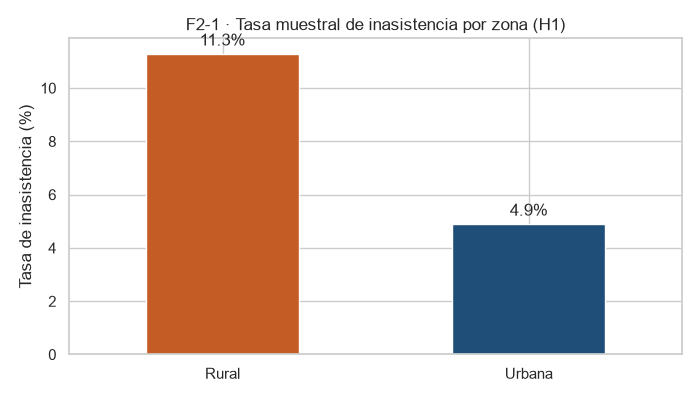

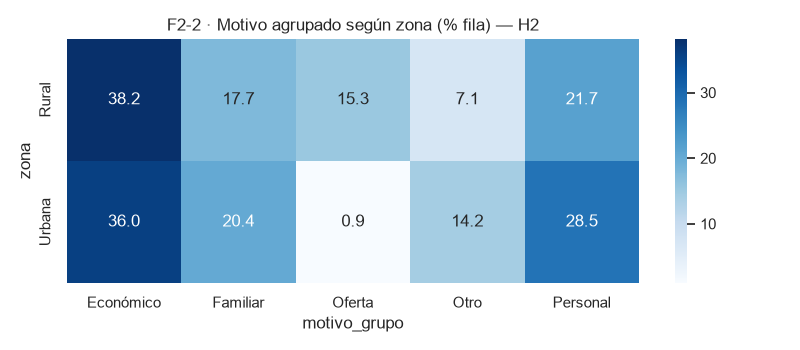

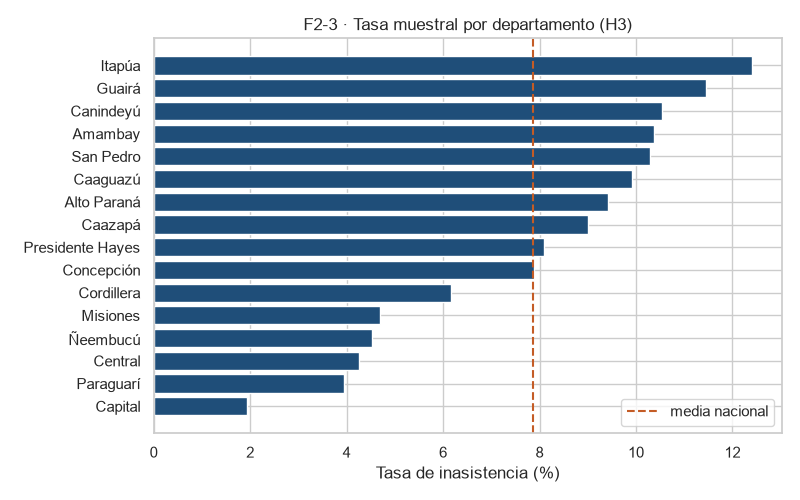

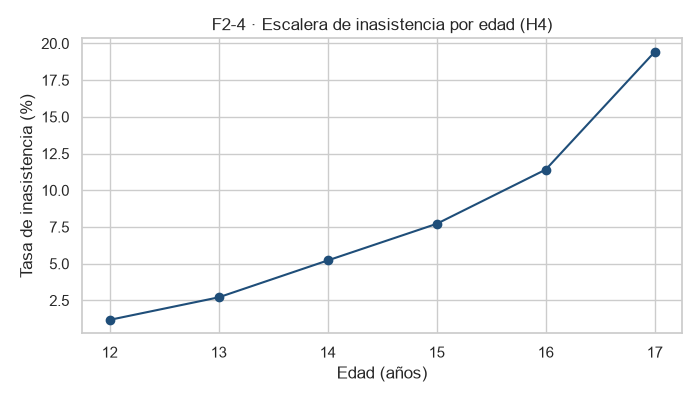

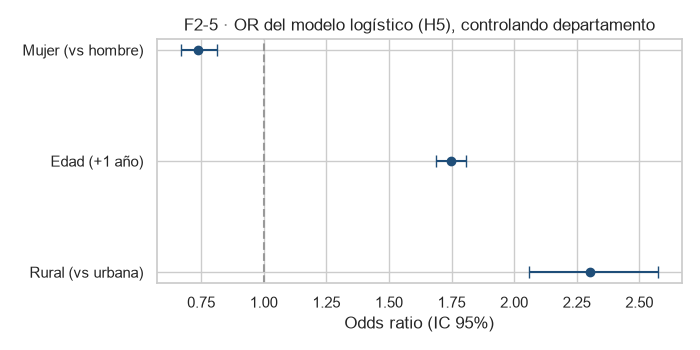

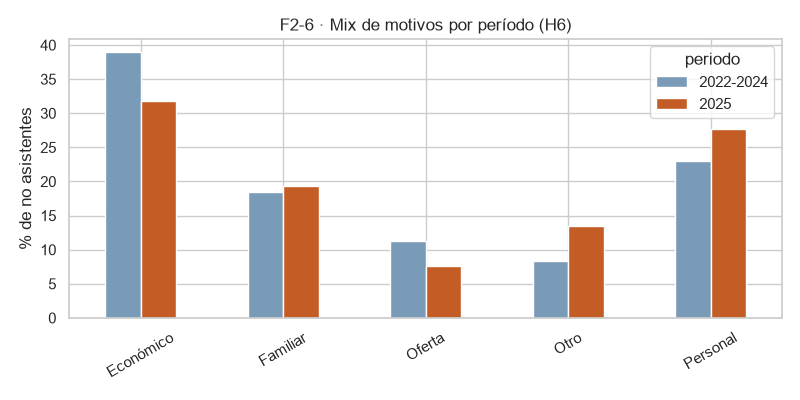

In [9]:
from IPython.display import Image, display
for name in ['F2_1_tasa_zona','F2_2_motivo_zona','F2_3_tasa_departamento',
             'F2_4_edad','F2_5_or_logistica','F2_6_motivo_periodo']:
    display(Image(filename=str(DIR_FIG / f'{name}.png')))


## 7. Conclusión de la Fase 2

### Qué se sostuvo y qué no
Tras BH (α=0.05), **H1, H2, H3, H4 y H6 se rechazan** a favor de las alternativas. **H5 también**:
el OR rural permanece >1 al controlar departamento, edad y sexo. Ninguna H₀ “se acepta”; donde el p
fuera grande diríamos *no hay evidencia suficiente para rechazarla*.

### Implicancia para la pregunta
Zona y departamento **sí se asocian** con la inasistencia más allá del azar muestral. Los motivos
**no son independientes** de la zona, y el mix de 2025 **no copia** el de 2022–2024. La edad empuja
la tasa hacia arriba. Eso refuerza el relato descriptivo de la Fase 1 con evidencia inferencial.

### Limitaciones de la inferencia
1. Diseño complejo (UPM/estratos): independencia imperfecta → p-valores optimistas.
2. Inferencia sobre n muestral, no con replicaciones DGEEC.
3. Motivo autorreportado; agrupación ad hoc.
4. H5 controla dpto/edad/sexo, **no** ingreso ni trabajo: no hay causalidad.
5. Observaciones de años distintos no son un panel de las mismas personas.

### Variables hacia la Fase 3
Predictores prioritarios: **zona (rural)**, **departamento**, **edad**, **sexo**.
Candidate opcional: **año/período** (por H6). Target: `no_asiste`. Línea base: clase mayoritaria
(“todos asisten”) o logística solo con zona.
